## 1. Non-Linear Analysis of Constraint Risk (South West)

This notebook explores whether constraint risk in the South West exhibits non-linear behaviour that is not captured by the baseline logistic regression model.

Previous analysis showed that system-level relationships between wind generation and constraint events do not hold consistently at the regional level. In the South West, the relationship appears weaker and potentially conditional on demand.

To investigate this further, a Random Forest classifier is applied using:

- GB wind generation (wind_mw)
- South West demand proxy (sw_demand_mw)

The objective is not to maximise predictive accuracy, but to:

- detect non-linear structure
- identify interaction effects between wind and demand
- understand whether constraint risk is concentrated in specific operating regimes

Model outputs are then validated against empirical data to ensure that observed patterns reflect real system behaviour rather than artefacts of the modelling approach.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, f1_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split

## 1. LOAD DATA

In [2]:
DATA_PROCESSED = "../data/processed/"

df = pd.read_csv(DATA_PROCESSED + "modelling_dataset_2022.csv")

print(df.shape)
df.head()

(17520, 6)


,date,sp,gspGroup,sw_demand_mw,sp_key,wind_mw
0,2022-01-01,1,_L,1128.2,2022-01-01_1,13265.0
1,2022-01-01,2,_L,1156.2,2022-01-01_2,13265.0
2,2022-01-01,3,_L,1134.0,2022-01-01_3,13265.0
3,2022-01-01,4,_L,1078.8,2022-01-01_4,13265.0
4,2022-01-01,5,_L,1020.0,2022-01-01_5,13265.0


## 2. PREP FEATURES

In [3]:
# =========================
# STEP 2 — ADD TARGET VARIABLE
# =========================

# Load events
events = pd.read_csv("../data/processed/sw_constraint_events_2022.csv")

# Keep only what we need
events = events[['sp_key', 'constraint_event']]

# Remove any old versions to avoid duplication bugs
df = df.drop(columns=[
    'constraint_event',
    'constraint_event_x',
    'constraint_event_y'
], errors='ignore')

# Merge cleanly
df = df.merge(
    events,
    on='sp_key',
    how='left'
)

# Fill missing = no constraint
df['constraint_event'] = df['constraint_event'].fillna(0)

# Check
print(df.columns)
print("Event rate:", df['constraint_event'].mean())

Index(['date', 'sp', 'gspGroup', 'sw_demand_mw', 'sp_key', 'wind_mw',
       'constraint_event'],
      dtype='object')
Event rate: 0.03139269406392694


## 3. TRAIN / TEST SPLIT

In [4]:
X = df[['wind_mw', 'sw_demand_mw']]
y = df['constraint_event']

print("Event rate:", y.mean())

Event rate: 0.03139269406392694


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [6]:
print(len(X_train), len(X_test))
print("Train event rate:", y_train.mean())
print("Test event rate:", y_test.mean())

12264 5256
Train event rate: 0.03139269406392694
Test event rate: 0.03139269406392694


## 4. RANDOM FOREST MODEL

In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [8]:
from sklearn.metrics import average_precision_score, f1_score

probs = rf.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, probs)
f1 = f1_score(y_test, (probs > 0.5))

print("PR AUC:", pr_auc)
print("F1 Score:", f1)

PR AUC: 0.06828415640666673
F1 Score: 0.0919229469415343


In [9]:
print("PR AUC:", pr_auc)

PR AUC: 0.06828415640666673


In [10]:
probs = rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import average_precision_score, f1_score

pr_auc = average_precision_score(y_test, probs)
f1 = f1_score(y_test, (probs > 0.5))

print("PR AUC:", pr_auc)
print("F1 Score:", f1)

PR AUC: 0.06828415640666673
F1 Score: 0.0919229469415343


In [11]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

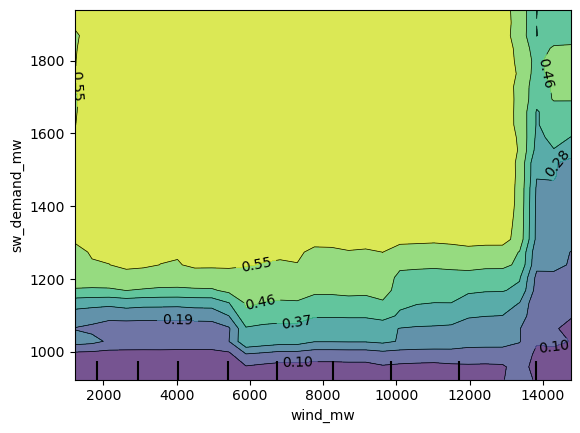

In [14]:
PartialDependenceDisplay.from_estimator(
    rf,
    X,
    [('wind_mw', 'sw_demand_mw')],
    grid_resolution=30,
    subsample=2000,
    random_state=42
)

In [15]:
# How many observations in that region?
mask = (
    (df['wind_mw'] > 2000) &
    (df['wind_mw'] < 13000) &
    (df['sw_demand_mw'] < 1500)
)

print("Rows in region:", mask.sum())
print("Event rate in region:", df.loc[mask, 'constraint_event'].mean())

Rows in region: 9558
Event rate in region: 0.030654948734044778


In [16]:
temp = df.copy()

temp['wind_bin'] = pd.qcut(temp['wind_mw'], 20, duplicates='drop')
temp['demand_bin'] = pd.qcut(temp['sw_demand_mw'], 20, duplicates='drop')

heatmap = (
    temp.groupby(['demand_bin', 'wind_bin'], observed=True)['constraint_event']
    .mean()
    .unstack()
)

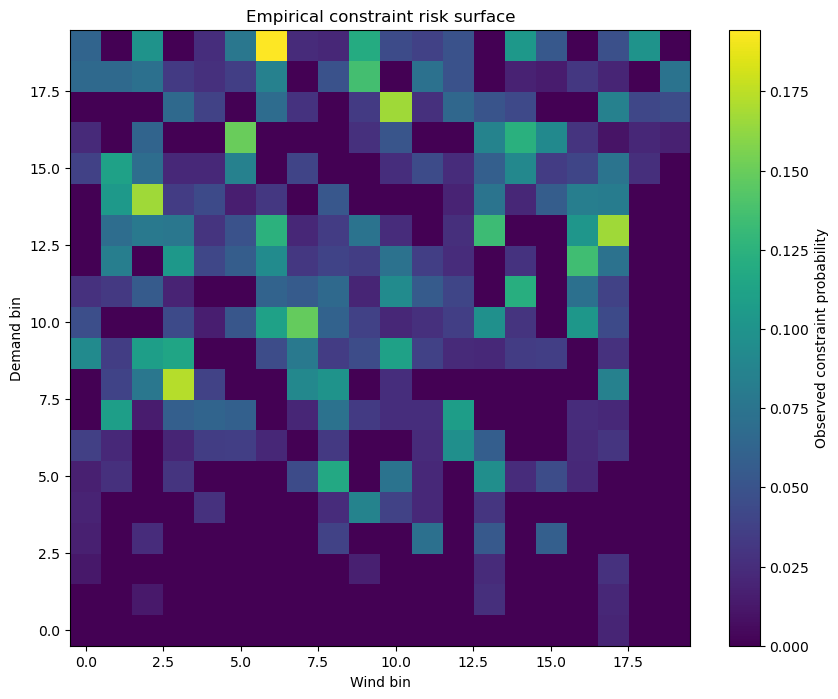

In [17]:
plt.figure(figsize=(10, 8))

plt.imshow(
    heatmap.values,
    aspect='auto',
    origin='lower'
)

plt.colorbar(label="Observed constraint probability")

plt.title("Empirical constraint risk surface")
plt.xlabel("Wind bin")
plt.ylabel("Demand bin")

plt.show()

## Interpretation

The Random Forest model suggests that constraint risk in the South West is not a simple monotonic function of wind generation. Instead, the model highlights regions of the wind–demand space where predicted risk appears elevated, particularly under conditions of:

- moderate to high wind generation
- low regional demand

This indicates that constraint risk may be influenced by combinations of system conditions, rather than a single dominant driver.

However, empirical validation using a binned heatmap of observed constraint events provides a more grounded view. The heatmap shows that:

- constraint events remain rare across all conditions (~3% baseline rate)
- no region exhibits dramatically elevated observed probabilities
- variation in risk across the wind–demand space is present, but modest

This reveals an important distinction between model behaviour and real data:

- the model captures structural patterns in the data
- but its predicted probabilities are not well calibrated and can exaggerate effects, particularly in an imbalanced dataset

## 5. EVALUATION (IMBALANCE-AWARE)

In [18]:
probs = rf.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, probs)
f1 = f1_score(y_test, (probs > 0.5))

print("PR AUC:", pr_auc)
print("F1 Score:", f1)

PR AUC: 0.06828415640666673
F1 Score: 0.0919229469415343


## 6. FEATURE IMPORTANCE

wind_mw         0.343785
sw_demand_mw    0.656215
dtype: float64


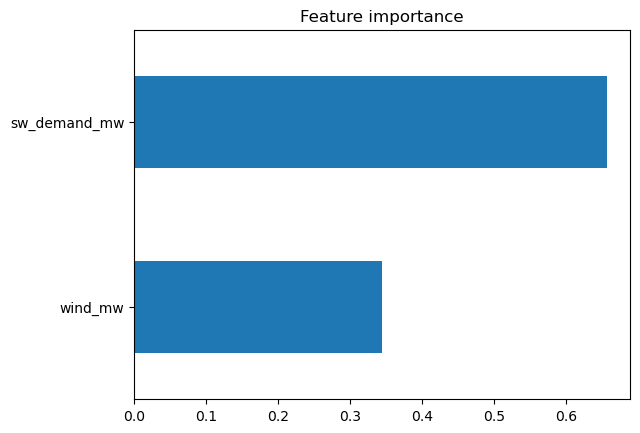

In [19]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

print(importances)

importances.plot(kind='barh')
plt.title("Feature importance")
plt.show()

## 7. PARTIAL DEPENDENCE (1D)

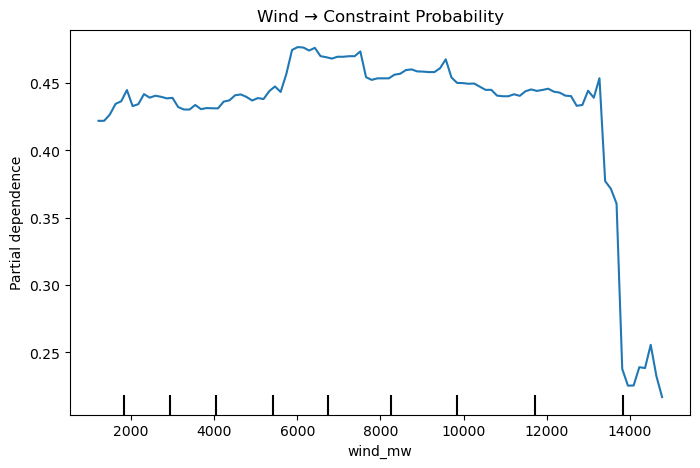

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

PartialDependenceDisplay.from_estimator(
    rf,
    X,
    ['wind_mw'],
    ax=ax
)

plt.title("Wind → Constraint Probability")
plt.show()

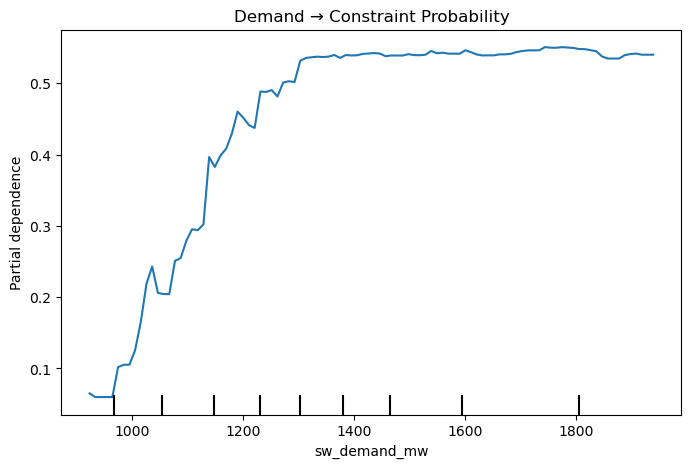

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

PartialDependenceDisplay.from_estimator(
    rf,
    X,
    ['sw_demand_mw'],
    ax=ax
)

plt.title("Demand → Constraint Probability")
plt.show()

## 8. Conclusion

Non-linear modelling confirms that constraint risk in the South West exhibits structural variation across the wind–demand space. However, this variation is subtle rather than extreme.

The key findings are:

- Constraint risk is not strongly driven by wind generation alone
- Interactions between wind and demand influence system behaviour
- Constraint events remain inherently rare across all operating conditions

Importantly, empirical analysis shows that the magnitude of these effects is limited, and that model-based probability surfaces should be interpreted with caution.

This supports the broader conclusion of the project:

System-level relationships do not directly translate to regional dynamics. In the South West, constraint behaviour is more nuanced, reflecting local network conditions and flows rather than a simple generation-driven mechanism.

Overall, non-linear models add value by revealing structure, but empirical validation is essential to ensure that conclusions remain grounded in observed system behaviour.

Non-linear models suggest where to look; empirical data determines what is real.

Constraint dynamics are better understood as a function of system state rather than individual variables.

## Appendix — Constraint Risk Regime Classification

In [22]:
df = pd.read_csv("../data/processed/modelling_dataset_2022.csv")

print(df.shape)
df.head()
print(df.columns)

(17520, 6)
Index(['date', 'sp', 'gspGroup', 'sw_demand_mw', 'sp_key', 'wind_mw'], dtype='object')


In [23]:
events = pd.read_csv("../notebooks/data/sw_constraint_events_2022.csv")

print(events.columns)

Index(['settlementDate', 'settlementPeriodFrom', 'sp_key', 'total_accepted_mw',
       'n_acceptances', 'n_bmus_active', 'constraint_event'],
      dtype='object')


In [24]:
df = df.merge(
    events[['sp_key', 'constraint_event']],
    on='sp_key',
    how='left'
)

In [25]:
df['constraint_event'] = df['constraint_event'].fillna(0)

In [26]:
print(df['constraint_event'].mean())

0.03139269406392694


In [27]:
baseline = df['constraint_event'].mean()

In [28]:
print(df.columns)

Index(['date', 'sp', 'gspGroup', 'sw_demand_mw', 'sp_key', 'wind_mw',
       'constraint_event'],
      dtype='object')


In [29]:
print(df['constraint_event'].isna().mean())

0.0


In [30]:
baseline = df['constraint_event'].mean()
print("Baseline event rate:", baseline)

Baseline event rate: 0.03139269406392694


In [31]:
demand_thresholds = [1200, 1400, 1600, 1800, 2000]
wind_thresholds = [4000, 6000, 8000, 10000, 12000]

results = []

for d in demand_thresholds:
    for w in wind_thresholds:
        mask = (
            (df['sw_demand_mw'] > d) &
            (df['wind_mw'] > w)
        )
        
        n = mask.sum()
        if n == 0:
            continue
        
        event_rate = df.loc[mask, 'constraint_event'].mean()
        
        results.append({
            'demand_min': d,
            'wind_min': w,
            'rows': n,
            'event_rate': event_rate
        })

results_df = pd.DataFrame(results)

# Sort by highest risk
results_df.sort_values('event_rate', ascending=False).head(10)

,demand_min,wind_min,rows,event_rate
23,2000,10000,102,0.068627
20,2000,4000,459,0.063181
21,2000,6000,345,0.060870
24,2000,12000,58,0.051724
15,1800,4000,1447,0.048376
16,1800,6000,1143,0.047244
11,1600,6000,2376,0.045034
10,1600,4000,2846,0.044273
19,1800,12000,283,0.042403
18,1800,10000,509,0.041257


In [32]:
HIGH_DEMAND = 1800
HIGH_WIND = 4000

mask = (
    (df['sw_demand_mw'] > HIGH_DEMAND) &
    (df['wind_mw'] > HIGH_WIND)
)

print("Rows:", mask.sum())
print("Event rate:", df.loc[mask, 'constraint_event'].mean())

Rows: 1447
Event rate: 0.04837595024187975


Constraint risk increases when demand exceeds 1800 MW and wind generation exceeds 4000 MW, with an observed event rate of ~4.8% (vs ~3.1% baseline) across 1,447 settlement periods.

In [33]:
low_mask = (df['sw_demand_mw'] < 1400) & (df['wind_mw'] < 5000)
high_mask = (df['sw_demand_mw'] > 1800) & (df['wind_mw'] > 4000)

print("Low zone %:", low_mask.mean())
print("High zone %:", high_mask.mean())

Low zone %: 0.25878995433789953
High zone %: 0.08259132420091324


In [34]:
df['date'] = pd.to_datetime(df['date'])

df['hour'] = (df['sp'] - 1) // 2  # SP → hour (0–23)
df['month'] = df['date'].dt.month

In [35]:
high_mask = (
    (df['sw_demand_mw'] > 1800) &
    (df['wind_mw'] > 4000)
)

In [36]:
hour_profile = df[high_mask].groupby('hour').size()
hour_profile = hour_profile / hour_profile.sum()

print(hour_profile.sort_values(ascending=False).head(10))

hour
17    0.127851
18    0.126469
19    0.099516
16    0.093988
15    0.065653
20    0.060124
9     0.060124
12    0.058742
13    0.056669
10    0.054596
dtype: float64


In [37]:
month_profile = df[high_mask].groupby('month').size()
month_profile = month_profile / month_profile.sum()

print(month_profile)

month
1     0.374568
2     0.211472
3     0.127851
11    0.056669
12    0.229440
dtype: float64


### Risk Regime Interpretation

The system can be broadly segmented into three regimes:

- Low-risk (Safe zone):  
  Demand < 1400 MW and wind < 5000 MW  
  → No observed constraint events  
  → Covers **~26% of settlement periods**
- Elevated-risk (Watch zone):  
  Demand > 1800 MW and wind > 4000 MW  
  → Constraint probability increases to ~ 4.8% (vs ~ 3.1% baseline)  
  → Covers **~8% of settlement periods**
- Neutral:  
  All other conditions  
  → Baseline constraint probability (~ 3%)

**Interpretation:**  
Constraint risk is a function of system state rather than a random process. A significant portion of the year (~ 26%) sits in a no-risk regime, while elevated-risk conditions are relatively rare (~ 8%) but associated with a meaningful increase in constraint probability. This provides a simple operational filter: exclude risk in the safe zone and focus attention when the system enters elevated-risk conditions.
Elevated-risk conditions occur predominantly during winter months (December–February) and peak demand hours (late afternoon to evening), consistent with system stress driven by high demand.